# Finalising a question

Using the logistic regression from O_4 as a lookup: given a down, yards to go, and offense formation, what is the model's P(dropback)?

This is the "predictability" building block - a play near P=0 or P=1 is highly predictable (run or pass), a play near P=0.5 is a coin flip.

In [8]:
#setup - load the data and fit the same logistic regression as O_4
import sys
sys.path.append('../src')

import pandas as pd

from dropback_analysis.features import build_features
from dropback_analysis.models import fit_logistic_regression, predict_dropback_probability

plays = pd.read_csv('/Users/seanlee/Desktop/Github_repositories/Practice-repo/data/plays.csv')
features = build_features(plays)

logit_model = fit_logistic_regression(features)
print('model fitted on', features.shape[0], 'plays')

Optimization terminated successfully.
         Current function value: 0.532276
         Iterations 7
model fitted on 15816 plays


## The function

predict_dropback_probability(model, down, yards_to_go, offense_formation) -> float in [0, 1].

In [9]:
down = 3
yards_to_go = 12
offense_formation = 'SHOTGUN'

p = predict_dropback_probability(logit_model, down, yards_to_go, offense_formation)
print(f'down {down}, {yards_to_go} to go, {offense_formation}: P(dropback) = {p:.3f}')

down 3, 12 to go, SHOTGUN: P(dropback) = 0.908


## Defensive alignment vs predictability

For each play, measure how the defense lines up at the snap (from tracking data): how many in the box, how many deep, how deep the secondary sits. Combine into one alignment_index (higher = more pass-ready). Then rank the 32 defenses on how pass-ready they align when the model says a dropback is coming.

In [10]:
#defensive alignment features from the snap-frame tracking data
import numpy as np


def defensive_alignment(snap_frames, plays):
    # one row per play: simple pre-snap defensive alignment features, measured at the snap
    ball = (
        snap_frames[snap_frames['displayName'] == 'football']
        [['gameId', 'playId', 'x', 'y']]
        .rename(columns={'x': 'los_x', 'y': 'ball_y'})
    )

    defenders = snap_frames.merge(plays[['gameId', 'playId', 'defensiveTeam']], on=['gameId', 'playId'])
    defenders = defenders[defenders['club'] == defenders['defensiveTeam']]
    defenders = defenders.merge(ball, on=['gameId', 'playId'])

    # yards downfield of the line of scrimmage, seen from the defense's side
    defenders['depth'] = np.where(
        defenders['playDirection'] == 'right',
        defenders['x'] - defenders['los_x'],
        defenders['los_x'] - defenders['x'],
    )
    defenders['off_ball_lateral'] = (defenders['y'] - defenders['ball_y']).abs()

    defenders['in_box'] = (defenders['depth'] <= 4) & (defenders['off_ball_lateral'] <= 4)
    defenders['is_deep'] = defenders['depth'] >= 10
    defenders['on_los'] = defenders['depth'] <= 2

    return (
        defenders.groupby(['gameId', 'playId'])
        .agg(
            n_defenders=('nflId', 'size'),
            box_count=('in_box', 'sum'),
            deep_count=('is_deep', 'sum'),
            on_los_count=('on_los', 'sum'),
            secondary_depth=('depth', lambda s: s.nlargest(4).mean()),
        )
        .reset_index()
    )


def add_alignment_index(alignment):
    # one score: higher = lighter box, more deep defenders, secondary sitting deeper -> more "pass-ready"
    def z(s):
        return (s - s.mean()) / s.std()

    index = (z(alignment['deep_count']) + z(alignment['secondary_depth']) - z(alignment['box_count'])) / 3

    return alignment.assign(alignment_index=index)

In [11]:
#snap-frame tracking (pre-extracted: every tracking_week_*.csv filtered to frameType == 'SNAP', ~370k rows)
snaps = pd.read_csv('/Users/seanlee/Desktop/Github_repositories/Practice-repo/data/snap_frames.csv')

alignment = add_alignment_index(defensive_alignment(snaps, plays))

scored = (
    features.assign(p_dropback=logit_model.predict(features))
    .merge(alignment, on=['gameId', 'playId'])
    .merge(plays[['gameId', 'playId', 'defensiveTeam']], on=['gameId', 'playId'])
)
scored = scored[scored['n_defenders'] == 11]          # keep clean 11-man plays
dropbacks = scored[scored['isDropback'] == True]

print(len(dropbacks), 'dropback plays with alignment data')
dropbacks[['defensiveTeam', 'down', 'yardsToGo', 'offenseFormation', 'p_dropback',
           'box_count', 'deep_count', 'secondary_depth', 'alignment_index']].head()

9713 dropback plays with alignment data


,defensiveTeam,down,yardsToGo,offenseFormation,p_dropback,box_count,deep_count,secondary_depth,alignment_index
0,ATL,1,10,EMPTY,0.948054,3,2,10.195000,0.418942
1,DAL,1,10,EMPTY,0.948054,2,2,9.767500,0.697512
2,TEN,3,12,SHOTGUN,0.907610,2,2,10.700000,0.825637
3,TEN,2,10,SHOTGUN,0.798412,2,2,9.062501,0.600646
7,DET,3,12,SHOTGUN,0.907610,4,1,8.527500,-0.549890


In [12]:
#rank the 32 defenses on how "pass-ready" they line up when a dropback is predictable
#  mean_index - avg alignment index on highly-predictable dropbacks (P >= 0.85), higher = more pass-ready
#  responsiveness - slope of alignment_index vs p_dropback across all dropbacks, higher = alignment tracks the tell
#  n - number of predictable dropbacks faced 

predictable = dropbacks[dropbacks['p_dropback'] >= 0.85]

ranking = (
    predictable.groupby('defensiveTeam')
    .agg(n=('alignment_index', 'size'), mean_index=('alignment_index', 'mean'))
)
ranking['responsiveness'] = dropbacks.groupby('defensiveTeam').apply(
    lambda g: np.polyfit(g['p_dropback'], g['alignment_index'], 1)[0], include_groups=False
)

ranking.sort_values('mean_index', ascending=False).round(3)

,n,mean_index,responsiveness
defensiveTeam,,,
DEN,101,0.616,1.125
LA,96,0.569,1.198
MIN,116,0.569,0.930
LV,84,0.518,1.253
SEA,118,0.497,1.023
CLE,75,0.494,1.204
PHI,108,0.465,1.216
NO,103,0.455,0.667
PIT,107,0.388,1.074


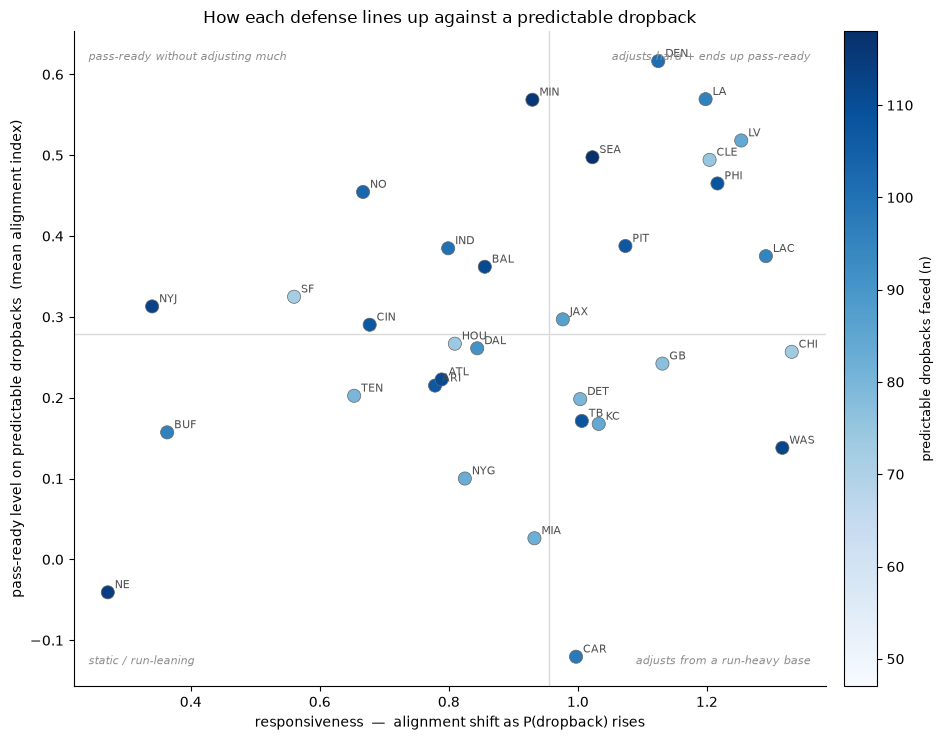

In [13]:
#one point per defense: how pass-ready they line up (y) vs how much that shifts with predictability (x)
import matplotlib.pyplot as plt

r = ranking.reset_index()
x_med, y_med = r['responsiveness'].median(), r['mean_index'].median()

fig, ax = plt.subplots(figsize=(10, 7.5))
ax.axvline(x_med, color='0.85', lw=1)
ax.axhline(y_med, color='0.85', lw=1)

pts = ax.scatter(r['responsiveness'], r['mean_index'], c=r['n'], cmap='Blues',
                 vmin=r['n'].min() - 25, s=90, edgecolor='0.4', linewidth=0.5, zorder=3)
for _, row in r.iterrows():
    ax.annotate(row['defensiveTeam'], (row['responsiveness'], row['mean_index']),
                xytext=(5, 3), textcoords='offset points', fontsize=8, color='0.3')

cbar = fig.colorbar(pts, ax=ax, pad=0.02)
cbar.set_label('predictable dropbacks faced (n)', fontsize=9)

ax.set_xlabel('responsiveness  —  alignment shift as P(dropback) rises')
ax.set_ylabel('pass-ready level on predictable dropbacks  (mean alignment index)')
ax.set_title('How each defense lines up against a predictable dropback', fontsize=12)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)

for xf, yf, ha, va, label in [
    (0.98, 0.97, 'right', 'top', 'adjusts hard + ends up pass-ready'),
    (0.02, 0.97, 'left', 'top', 'pass-ready without adjusting much'),
    (0.98, 0.03, 'right', 'bottom', 'adjusts from a run-heavy base'),
    (0.02, 0.03, 'left', 'bottom', 'static / run-leaning'),
]:
    ax.text(xf, yf, label, transform=ax.transAxes, ha=ha, va=va,
            fontsize=8, style='italic', color='0.55')

plt.tight_layout()
plt.show()

In [ ]:
logit_model.predict()

array([0.94805433, 0.94805433, 0.90760999, ..., 0.68061517, 0.32331595,
       0.32331595], shape=(15816,))